In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import microns_datacleaner as mic
import microns_datacleaner.filters as fl

In [7]:
cleaner = mic.MicronsDataCleaner(datadir="data/", version=1718, download_policy='minimum')
units, segments = cleaner.process_nucleus_data(functional_data='best_only')

matched = units[units['tuning_type'] == 'matched']
proofread_matched = matched[matched['strategy_axon'] != 'none']

print(f"Total cells: {len(units)}")
print(f"Functionally matched: {len(matched)}")
print(f"Matched + proofread: {len(proofread_matched)}")

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 98817.22it/s] 


Total cells: 90434
Functionally matched: 13005
Matched + proofread: 906


In [9]:
[c for c in cohort.columns if 'unit' in c.lower() or 'session' in c or 'scan' in c]

['session', 'scan_idx', 'unit_id']

In [10]:
SESSION = 9
SCAN = 3

# Filter to one specific scan
cohort = proofread_matched[
    (proofread_matched['session'] == SESSION) & 
    (proofread_matched['scan_idx'] == SCAN)
].reset_index(drop=True)

# Add a stable index for matching with the structural matrix later
cohort['matrix_index'] = np.arange(len(cohort))

print(f"Cohort: {len(cohort)} neurons in session {SESSION}, scan {SCAN}")

# unit_id is the index used to look up the neuron's trace in microns.h5
unit_ids = cohort['unit_id'].astype(int).values
print(f"unit_ids shape: {unit_ids.shape}")
print(f"unit_ids range: {unit_ids.min()} to {unit_ids.max()}")

Cohort: 99 neurons in session 9, scan 3
unit_ids shape: (99,)
unit_ids range: 1521 to 8608


In [12]:
funcreader = mic.MicronsFunctionalReader(path="data/functional/microns_functional.h5")
print("Connected to functional data")

Connected to functional data


In [13]:
sesh_scan = f"{SESSION}_{SCAN}"

trial_responses = []
trial = 0

while True:
    try:
        r = funcreader.get_trial(sesh_scan, trial, "V1")
        trial_responses.append(r['responses'])
        trial += 1
    except Exception as e:
        print(f"Stopped at trial {trial}: {type(e).__name__}")
        break

print(f"Found {trial} trials in scan {sesh_scan}")
if trial_responses:
    print(f"First trial shape (all V1 neurons × frames): {trial_responses[0].shape}")

Stopped at trial 464: ValueError
Found 464 trials in scan 9_3
First trial shape (all V1 neurons × frames): (5838, 75)


In [23]:
import h5py

with h5py.File("data/functional/microns_functional.h5", "r") as f:
    print("Keys under sessions/9_3:")
    for k in f["sessions/9_3"].keys():
        print(f"  {k}")
    
    print("\nKeys under sessions/9_3/meta:")
    for k in f["sessions/9_3/meta"].keys():
        print(f"  {k}")

Keys under sessions/9_3:
  meta
  trials

Keys under sessions/9_3/meta:
  area_indices
  brain_areas
  condition_hashes
  coordinates
  unit_ids


In [24]:
import h5py

with h5py.File("data/functional/microns_functional.h5", "r") as f:
    print("Keys under sessions/9_3/meta/area_indices:")
    for k in f["sessions/9_3/meta/area_indices"].keys():
        print(f"  {k}")

Keys under sessions/9_3/meta/area_indices:
  AL
  LM
  RL
  V1


In [25]:
with h5py.File("data/functional/microns_functional.h5", "r") as f:
    all_unit_ids = f[f"sessions/{sesh_scan}/meta/unit_ids"][:]
    v1_indices = f[f"sessions/{sesh_scan}/meta/area_indices/V1"][:]

# Unit_ids of the V1 neurons in the order get_trial returns them
v1_unit_ids = all_unit_ids[v1_indices]
print(f"V1 unit_ids in scan {sesh_scan}: {len(v1_unit_ids)} neurons")

# Build a lookup: unit_id -> row index in the V1 response matrix
unit_id_to_row = {int(uid): i for i, uid in enumerate(v1_unit_ids)}

# Find row indices for our cohort
cohort_unit_ids = cohort['unit_id'].astype(int).values
missing = [uid for uid in cohort_unit_ids if uid not in unit_id_to_row]
print(f"Cohort unit_ids missing from V1 list: {len(missing)}")

cohort_rows = np.array([unit_id_to_row[uid] for uid in cohort_unit_ids if uid in unit_id_to_row])
print(f"Cohort rows: shape {cohort_rows.shape}, range {cohort_rows.min()} to {cohort_rows.max()}")

V1 unit_ids in scan 9_3: 5838 neurons
Cohort unit_ids missing from V1 list: 6
Cohort rows: shape (93,), range 1180 to 5817


In [26]:
# Keep only cohort neurons that are present in the V1 response matrix
cohort = cohort[cohort['unit_id'].isin(unit_id_to_row)].reset_index(drop=True)
cohort['matrix_index'] = np.arange(len(cohort))

# Recompute the row indices in the V1 response matrix
cohort_rows = np.array([unit_id_to_row[int(uid)] for uid in cohort['unit_id']])

print(f"Final cohort: {len(cohort)} neurons")
print(f"cohort_rows shape: {cohort_rows.shape}")

Final cohort: 93 neurons
cohort_rows shape: (93,)


In [27]:
# Extract our cohort's traces from each trial and concatenate
my_traces = [resp[cohort_rows, :] for resp in trial_responses]
traces = np.concatenate(my_traces, axis=1)

print(f"Traces shape: {traces.shape}")
print(f"  ({traces.shape[0]} neurons × {traces.shape[1]} time frames)")

Traces shape: (93, 37840)
  (93 neurons × 37840 time frames)


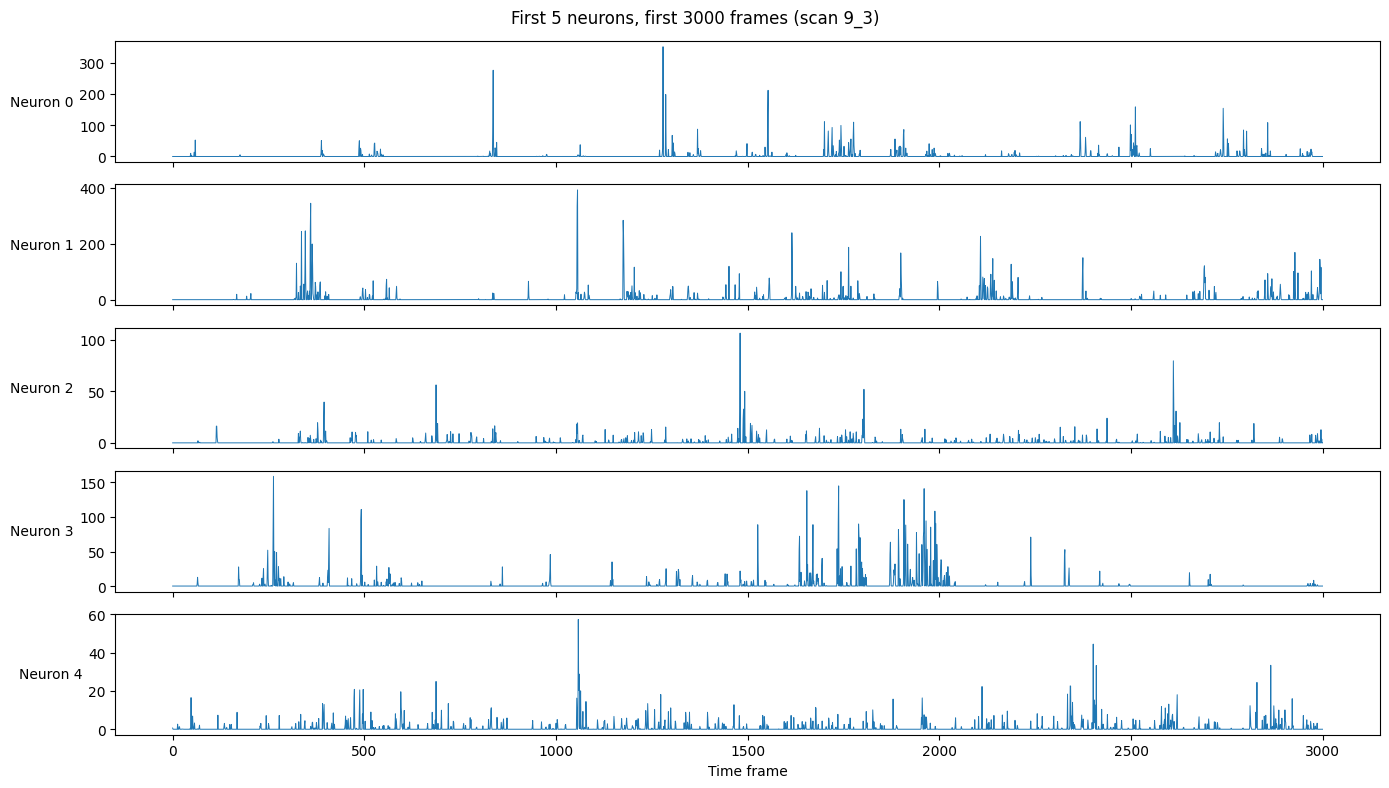

Neurons with near-zero variance (likely dead): 0


In [28]:
# Plot 5 example neurons to make sure traces look real
fig, axes = plt.subplots(5, 1, figsize=(14, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(traces[i, :3000], linewidth=0.7)
    ax.set_ylabel(f'Neuron {i}', rotation=0, ha='right', va='center')
axes[-1].set_xlabel('Time frame')
plt.suptitle(f'First 5 neurons, first 3000 frames (scan {sesh_scan})')
plt.tight_layout()
plt.show()

# Check for dead neurons (flat traces would break correlations with NaN)
trace_stds = traces.std(axis=1)
n_dead = (trace_stds < 1e-6).sum()
print(f"Neurons with near-zero variance (likely dead): {n_dead}")

In [29]:
F = np.corrcoef(traces)

print(f"Functional matrix shape: {F.shape}")
print(f"Diagonal (should all be 1.0): {F.diagonal()[:5]}")
print(f"Symmetric? F[5,10]={F[5,10]:.4f}, F[10,5]={F[10,5]:.4f}")
print(f"Any NaNs? {np.isnan(F).any()}")

Functional matrix shape: (93, 93)
Diagonal (should all be 1.0): [1. 1. 1. 1. 1.]
Symmetric? F[5,10]=-0.0021, F[10,5]=-0.0021
Any NaNs? False


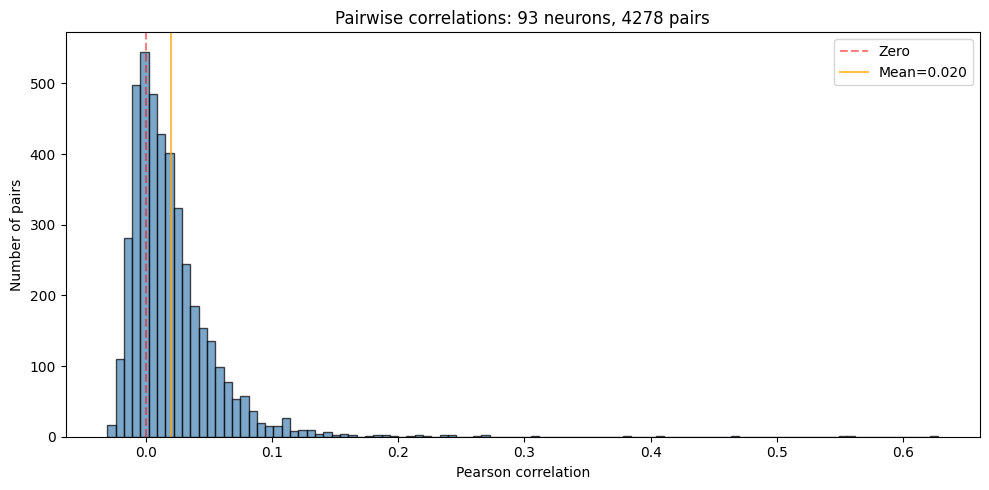

Mean: 0.0198
Median: 0.0117
Std: 0.0367
Min: -0.0306, Max: 0.6280
Pairs with r > 0.2: 18 (0.4%)
Pairs with r > 0.3: 7 (0.2%)


In [30]:
# Get all unique pairs (upper triangle, excluding diagonal)
upper = F[np.triu_indices_from(F, k=1)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(upper, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Zero')
ax.axvline(upper.mean(), color='orange', linestyle='-', alpha=0.7, label=f'Mean={upper.mean():.3f}')
ax.set_xlabel('Pearson correlation')
ax.set_ylabel('Number of pairs')
ax.set_title(f'Pairwise correlations: {len(cohort)} neurons, {len(upper)} pairs')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {upper.mean():.4f}")
print(f"Median: {np.median(upper):.4f}")
print(f"Std: {upper.std():.4f}")
print(f"Min: {upper.min():.4f}, Max: {upper.max():.4f}")
print(f"Pairs with r > 0.2: {(upper > 0.2).sum()} ({100*(upper > 0.2).mean():.1f}%)")
print(f"Pairs with r > 0.3: {(upper > 0.3).sum()} ({100*(upper > 0.3).mean():.1f}%)")

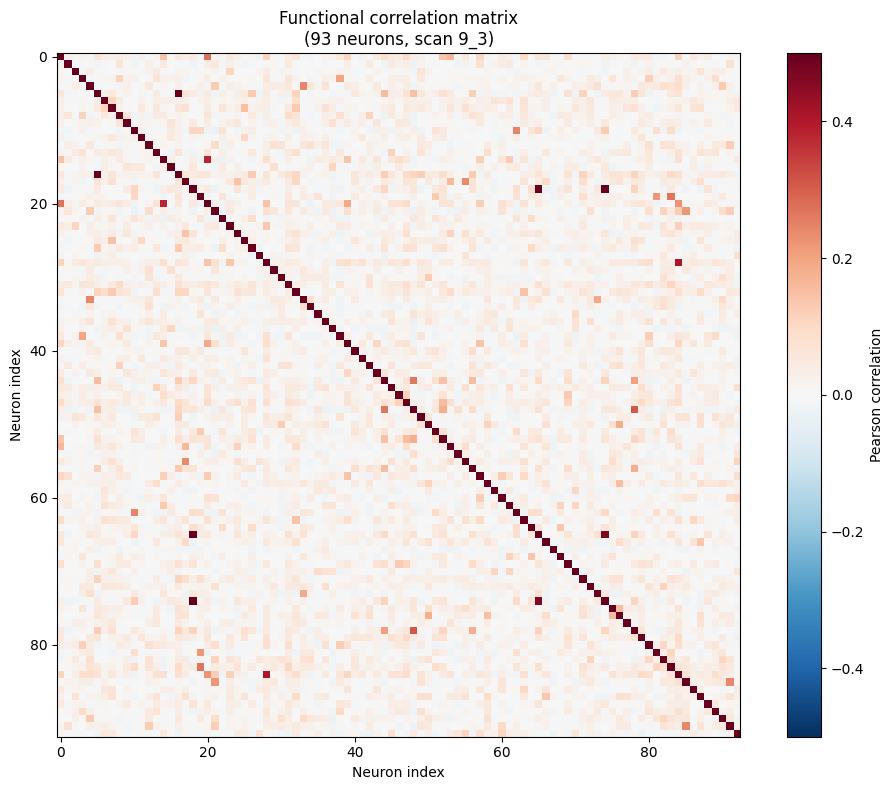

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(F, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title(f'Functional correlation matrix\n({len(cohort)} neurons, scan {sesh_scan})')
ax.set_xlabel('Neuron index')
ax.set_ylabel('Neuron index')
plt.tight_layout()
plt.show()

In [32]:
import os
import json

out_dir = 'outputs/functional_network'
os.makedirs(out_dir, exist_ok=True)

# Save the correlation matrix
np.save(f'{out_dir}/F_correlation_matrix.npy', F)

# Save the cohort with matrix indices so other notebooks can align
cohort_to_save = cohort[[
    'matrix_index', 'nucleus_id', 'pt_root_id', 'classification_system',
    'cell_type', 'layer', 'brain_area', 'strategy_axon', 'strategy_dendrite',
    'pt_position_x', 'pt_position_y', 'pt_position_z',
    'session', 'scan_idx', 'unit_id', 'cc_abs'
]].copy()
cohort_to_save.to_csv(f'{out_dir}/functional_cohort.csv', index=False)

# Save metadata about how the network was built
metadata = {
    'session': int(SESSION),
    'scan': int(SCAN),
    'n_neurons': int(len(cohort)),
    'n_trials': int(trial),
    'n_time_frames': int(traces.shape[1]),
    'correlation_method': 'pearson',
    'data_source': 'concatenated trials, V1 only',
    'mean_correlation': float(upper.mean()),
    'median_correlation': float(np.median(upper)),
    'pairs_above_0.2': int((upper > 0.2).sum()),
    'pairs_above_0.3': int((upper > 0.3).sum()),
}
with open(f'{out_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {out_dir}/")
print(f"  F_correlation_matrix.npy: {F.shape}")
print(f"  functional_cohort.csv: {len(cohort)} neurons")
print(f"  metadata.json")

Saved to outputs/functional_network/
  F_correlation_matrix.npy: (93, 93)
  functional_cohort.csv: 93 neurons
  metadata.json
